# Predicción de Combates de la UFC mediante Redes Neuronales Profundas

### Introducción al Proyecto
Este proyecto desarrolla un sistema de inteligencia artificial diseñado para predecir el resultado de los combates de la **Ultimate Fighting Championship (UFC)**. A diferencia de las estadísticas deportivas convencionales, este modelo utiliza una **Red Neuronal Profunda** para entender las complejas interacciones físicas, técnicas y biológicas entre dos atletas en el octágono.

In [63]:
import tensorflow as tf
import pandas as pd
import seaborn as sb
import numpy as np
import dotenv as dt
import os

dt.load_dotenv()
pd.set_option('display.max_columns', None) # para que me muestre todas las columnas

## 1. Carga de datos y exploración de datasets

En esta primera etapa, importamos las herramientas necesarias y cargamos las fuentes de información. Para este modelo, hemos utilizado dos conjuntos de datos complementarios que nos permiten tener una visión 360° de cada combate:

### Descripción de las fuentes:

1. **Dataset de Peleas (`ufc_gold_dataset_final.csv`):**
   * Contiene el registro histórico de los enfrentamientos.
   * Incluye información crítica como la fecha del evento, el método de victoria (KO, Sumisión, Decisión), el asalto en el que terminó y quién fue el ganador.
   * Es la base para definir nuestras etiquetas de entrenamiento (quién gana y quién pierde).

2. **Dataset de Luchadores (`ufc_fighters_final.csv`):**
   * Contiene la ficha técnica de cada atleta.
   * Incluye datos físicos (altura, alcance, peso), fecha de nacimiento y su guardia o estilo de combate (*Stance*).
   * Estos datos estáticos se cruzarán con el historial de peleas para calcular variables dinámicas como la edad del luchador en el momento exacto del combate.

Al combinar ambos, logramos transformar datos brutos en **información con contexto temporal**, fundamental para que la red neuronal entienda no solo quién es el peleador, sino en qué momento de su carrera se encontraba al subir al octágono.

In [64]:
# leemos el archivo de peleadores

path_peleadores = os.getenv("FIGHTERS_PATH")

df_fighters = pd.read_csv(path_peleadores)

df_fighters.head()

,Fighter_Name,Height,Weight,Reach,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Fighter_URL
0,Tom Aaron,NaN,155 lbs.,NaN,NaN,1978-07-13,5,3,0,0.00,0%,0.00,0%,0.00,0%,0%,0.0,http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny Abbadi,"5' 11""",155 lbs.,NaN,Orthodox,1983-07-03,4,6,0,3.29,38%,4.41,57%,0.00,0%,77%,0.0,http://ufcstats.com/fighter-details/15df64c02b...
2,Nariman Abbasov,"5' 8""",155 lbs.,"66.0""",Orthodox,1994-02-01,28,4,0,3.00,20%,5.67,46%,0.00,0%,66%,0.0,http://ufcstats.com/fighter-details/59a9d6dac6...
3,Darion Abbey,"6' 2""",265 lbs.,"80.0""",Orthodox,1993-02-25,9,5,0,8.44,50%,14.06,28%,0.00,0%,0%,0.0,http://ufcstats.com/fighter-details/4961467134...
4,David Abbott,"6' 0""",265 lbs.,NaN,Switch,1965-04-26,10,15,0,1.35,30%,3.55,38%,1.07,33%,66%,0.0,http://ufcstats.com/fighter-details/b361180739...


In [65]:
# leemos el archivo de peleas

path_peleas = os.getenv("FIGHTS_PATH")

df_fights = pd.read_csv(path_peleas)

df_fights.head()

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,F1_KD,F2_KD,F1_Sig_Landed,F1_Sig_Att,F2_Sig_Landed,F2_Sig_Att,F1_TD_Landed,F2_TD_Landed,F1_TD_Att,F2_TD_Att,F1_Sub_Att,F2_Sub_Att,F1_Ctrl_Sec,F2_Ctrl_Sec,F1_Head,F2_Head,F1_Body,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date
0,http://ufcstats.com/fight-details/4acab67848e7...,Scott Morris,Sean Daugherty,Scott Morris,Open Weight Bout,Submission,1,0:20,20,No Time Limit,0,0,1,1,0,4,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1994-03-11
1,http://ufcstats.com/fight-details/4b9ae533ccb3...,Patrick Smith,Ray Wizard,Patrick Smith,Open Weight Bout,Submission,1,0:58,58,No Time Limit,0,0,1,1,1,1,0,0,1,0,1,0,0,0,0,0,1,0,0,1,0,1,1,0,0,0,1994-03-11
2,http://ufcstats.com/fight-details/00835554f95f...,Royce Gracie,Patrick Smith,Royce Gracie,UFC 2 Tournament Title Bout,KO/TKO,1,1:17,77,No Time Limit,0,0,4,4,1,2,1,0,2,0,0,0,0,0,3,0,0,1,1,0,0,0,1,1,3,0,1994-03-11
3,http://ufcstats.com/fight-details/aa161c715974...,Royce Gracie,Remco Pardoel,Royce Gracie,Open Weight Bout,Submission,1,1:31,91,No Time Limit,0,0,0,0,0,0,1,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1994-03-11
4,http://ufcstats.com/fight-details/8fbdde20b712...,Patrick Smith,Johnny Rhodes,Patrick Smith,Open Weight Bout,Submission,1,1:07,67,No Time Limit,0,0,5,12,4,9,0,0,0,0,1,0,0,0,1,2,2,0,2,2,3,4,2,0,0,0,1994-03-11


### Analisis y limpieza fighters

In [66]:
# Verificación de valores nulos
print("Nulos en Peleadores:\n", df_fighters.isnull().sum())

# Estadísticas descriptivas básicas
display(df_fighters.describe())

Nulos en Peleadores:
 Fighter_Name       0
Height           318
Weight            86
Reach           1940
Stance           849
DOB              506
Wins               0
Losses             0
Draws              0
SLpM               0
Str_Acc            0
SApM               0
Str_Def            0
TD_Avg             0
TD_Acc             0
TD_Def             0
Sub_Avg            0
Fighter_URL        0
dtype: int64


,Wins,Losses,Draws,SLpM,SApM,TD_Avg,Sub_Avg
count,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000
mean,12.446689,5.687318,0.252076,2.502442,3.239360,1.255713,0.572907
std,9.208885,5.021361,0.796817,2.014610,2.943422,1.939531,1.441928
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,2.000000,0.000000,0.900000,1.660000,0.000000,0.000000
50%,11.000000,4.000000,0.000000,2.410000,2.990000,0.600000,0.000000
75%,17.000000,8.000000,0.000000,3.690000,4.305000,1.940000,0.700000
max,253.000000,83.000000,11.000000,20.950000,52.500000,32.140000,21.900000


In [67]:
# Vamos a convertir todos los porcentajes a decimales y las distancias de pulgadas a centimetros

# Limpieza de porcentajes
cols_pct = ['Str_Acc', 'Str_Def', 'TD_Acc', 'TD_Def']
for col in cols_pct:
    df_fighters[col] = df_fighters[col].str.rstrip('%').astype('float') / 100.0

# Limpieza de Peso (Weight)
df_fighters['Weight'] = df_fighters['Weight'].str.replace(' lbs.', '').astype(float)

print("Porcentajes y pesos convertidos a números.")
df_fighters[cols_pct + ['Weight']].describe()

Porcentajes y pesos convertidos a números.


,Str_Acc,Str_Def,TD_Acc,TD_Def,Weight
count,4455.000000,4455.000000,4455.000000,4455.000000,4369.000000
mean,0.360278,0.428864,0.260117,0.401639,170.070039
std,0.201409,0.219416,0.280530,0.343445,39.577608
min,0.000000,0.000000,0.000000,0.000000,105.000000
25%,0.280000,0.360000,0.000000,0.000000,145.000000
50%,0.410000,0.500000,0.230000,0.450000,160.000000
75%,0.490000,0.570000,0.440000,0.670000,185.000000
max,1.000000,1.000000,1.000000,1.000000,770.000000


In [68]:
# ahora convertimos el alcance y la altura a centimetros

def parse_height(height_str):
    if pd.isna(height_str) or height_str == '':
        return np.nan
    try:
        # Formato: 5' 11"
        parts = height_str.replace('"', '').split("' ")
        feet = int(parts[0])
        inches = int(parts[1])
        return (feet * 30.48) + (inches * 2.54)
    except:
        return np.nan

def parse_reach(reach_str):
    if pd.isna(reach_str) or reach_str == '':
        return np.nan
    try:
        # Formato: 70.0"
        return float(reach_str.replace('"', '')) * 2.54
    except:
        return np.nan

# 1. Convertir Height a cm
df_fighters['Height_cm'] = df_fighters['Height'].apply(parse_height)

# 2. Convertir Reach a cm
df_fighters['Reach_cm'] = df_fighters['Reach'].apply(parse_reach)

In [69]:
df_fighters.head()

,Fighter_Name,Height,Weight,Reach,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Fighter_URL,Height_cm,Reach_cm
0,Tom Aaron,NaN,155.0,NaN,NaN,1978-07-13,5,3,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/93fe7332d1...,NaN,NaN
1,Danny Abbadi,"5' 11""",155.0,NaN,Orthodox,1983-07-03,4,6,0,3.29,0.38,4.41,0.57,0.00,0.00,0.77,0.0,http://ufcstats.com/fighter-details/15df64c02b...,180.34,NaN
2,Nariman Abbasov,"5' 8""",155.0,"66.0""",Orthodox,1994-02-01,28,4,0,3.00,0.20,5.67,0.46,0.00,0.00,0.66,0.0,http://ufcstats.com/fighter-details/59a9d6dac6...,172.72,167.64
3,Darion Abbey,"6' 2""",265.0,"80.0""",Orthodox,1993-02-25,9,5,0,8.44,0.50,14.06,0.28,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/4961467134...,187.96,203.20
4,David Abbott,"6' 0""",265.0,NaN,Switch,1965-04-26,10,15,0,1.35,0.30,3.55,0.38,1.07,0.33,0.66,0.0,http://ufcstats.com/fighter-details/b361180739...,182.88,NaN


In [70]:
from sklearn.linear_model import LinearRegression

df_fighters['Is_Reach_Imputed'] = False

# 1. Filtramos los datos donde tenemos ambos valores
train_data = df_fighters[df_fighters['Height_cm'].notna() & df_fighters['Reach_cm'].notna()].copy()

X_train = train_data[['Height_cm']]
y_train = train_data['Reach_cm']

# 2. Entrenamos el modelo
model_reach = LinearRegression()
model_reach.fit(X_train, y_train)

# 3. Identificamos nulos de Reach donde SÍ hay Height
missing_reach_mask = df_fighters['Reach_cm'].isna() & df_fighters['Height_cm'].notna()

# --- MEJORA 2: Marcar las filas que vamos a cambiar ---
df_fighters.loc[missing_reach_mask, 'Is_Reach_Imputed'] = True

# 4. Predicción e Imputación
if missing_reach_mask.any():
    preds = model_reach.predict(df_fighters.loc[missing_reach_mask, ['Height_cm']])
    df_fighters.loc[missing_reach_mask, 'Reach_cm'] = preds

# Si un peleador no tiene ni Height ni Reach, la regresión no puede actuar.
# Para no perder esas filas en la Red, usamos la media del total.
if df_fighters['Reach_cm'].isna().any():
    df_fighters['Reach_cm'] = df_fighters['Reach_cm'].fillna(df_fighters['Reach_cm'].mean())
    print("Nota: Algunos valores se llenaron con la media global por falta de altura.")

print(f"✅ Se han imputado {missing_reach_mask.sum()} valores de Reach usando Regresión Lineal.")

Nota: Algunos valores se llenaron con la media global por falta de altura.
✅ Se han imputado 1623 valores de Reach usando Regresión Lineal.


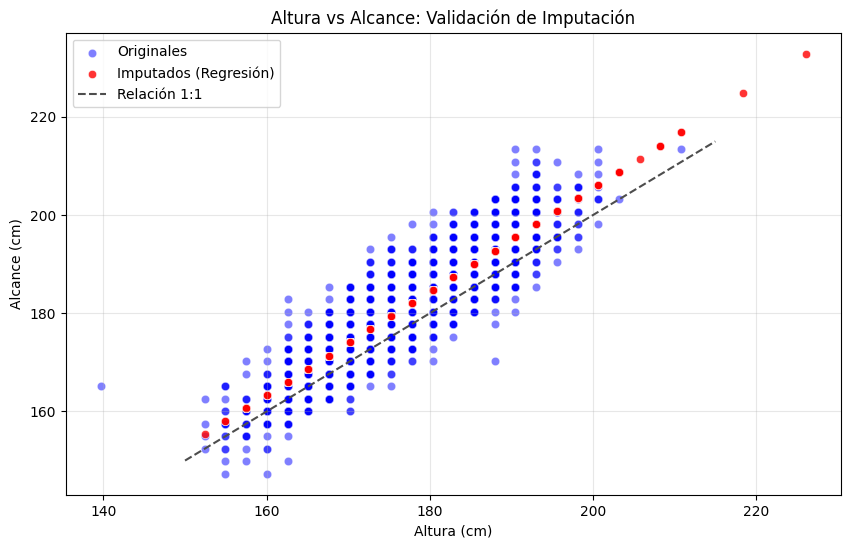

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# --- CAMBIO AQUÍ: Usamos 'Is_Reach_Imputed' que es el nombre real en el DataFrame ---

# Dibujar datos originales
sns.scatterplot(data=df_fighters[df_fighters['Is_Reach_Imputed'] == False], 
                x='Height_cm', y='Reach_cm', alpha=0.5, label='Originales', color='blue')

# Dibujar datos imputados
sns.scatterplot(data=df_fighters[df_fighters['Is_Reach_Imputed'] == True], 
                x='Height_cm', y='Reach_cm', alpha=0.8, label='Imputados (Regresión)', color='red')

# ----------------------------------------------------------------------------------

# Dibujar la línea de identidad (donde Altura == Alcance) para referencia
plt.plot([150, 215], [150, 215], ls="--", c=".3", label='Relación 1:1')

plt.title('Altura vs Alcance: Validación de Imputación')
plt.xlabel('Altura (cm)')
plt.ylabel('Alcance (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Se observa que los puntos rojos estan por encima de la linea de la regresion, porque los peleadores de elite suelen tener un alcance mayor a su altura, eso es conciderado una caracteristica de "elite"

In [72]:
df_fighters.head()

,Fighter_Name,Height,Weight,Reach,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Fighter_URL,Height_cm,Reach_cm,Is_Reach_Imputed
0,Tom Aaron,NaN,155.0,NaN,NaN,1978-07-13,5,3,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/93fe7332d1...,NaN,182.455373,False
1,Danny Abbadi,"5' 11""",155.0,NaN,Orthodox,1983-07-03,4,6,0,3.29,0.38,4.41,0.57,0.00,0.00,0.77,0.0,http://ufcstats.com/fighter-details/15df64c02b...,180.34,184.745690,True
2,Nariman Abbasov,"5' 8""",155.0,"66.0""",Orthodox,1994-02-01,28,4,0,3.00,0.20,5.67,0.46,0.00,0.00,0.66,0.0,http://ufcstats.com/fighter-details/59a9d6dac6...,172.72,167.640000,False
3,Darion Abbey,"6' 2""",265.0,"80.0""",Orthodox,1993-02-25,9,5,0,8.44,0.50,14.06,0.28,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/4961467134...,187.96,203.200000,False
4,David Abbott,"6' 0""",265.0,NaN,Switch,1965-04-26,10,15,0,1.35,0.30,3.55,0.38,1.07,0.33,0.66,0.0,http://ufcstats.com/fighter-details/b361180739...,182.88,187.418674,True


In [73]:
# 1. Extraemos los números del texto de la columna 'Weight' y los convertimos a decimal (float)
df_fighters['Weight_lb'] = df_fighters['Weight'].astype(str).str.extract('(\d+)').astype(float)

# 2. Convertimos las libras a kilogramos (1 lb ≈ 0.453 kg)
df_fighters['Weight_kg'] = df_fighters['Weight_lb'] * 0.453592

# 3. Limpieza estricta: Eliminamos a los luchadores que no tengan el peso registrado
# Es mejor trabajar con menos datos pero que sean reales, que inventar valores.
if df_fighters['Weight_kg'].isna().any():
    filas_antes = len(df_fighters)
    df_fighters = df_fighters.dropna(subset=['Weight_kg'])
    filas_despues = len(df_fighters)
    print(f"⚠️ Se eliminaron {filas_antes - filas_despues} registros por falta de datos en el peso.")

print("✅ Peso procesado y registros incompletos eliminados.")
display(df_fighters[['Fighter_Name', 'Weight_lb', 'Weight_kg']].head())

⚠️ Se eliminaron 86 registros por falta de datos en el peso.
✅ Peso procesado y registros incompletos eliminados.


,Fighter_Name,Weight_lb,Weight_kg
0,Tom Aaron,155.0,70.30676
1,Danny Abbadi,155.0,70.30676
2,Nariman Abbasov,155.0,70.30676
3,Darion Abbey,265.0,120.20188
4,David Abbott,265.0,120.20188


In [74]:
# Definimos los criterios de "Inexistencia de Información"

# 1. Sin medidas físicas (Si no hay altura, la regresión no pudo actuar)
sin_fisico = df_fighters['Height_cm'].isna()

# 2. Sin Fecha de Nacimiento (Imposible calcular edad)
sin_dob = df_fighters['DOB'].isna()

# 3. Sin historial de combate (0 victorias Y 0 derrotas)
# Si tiene al menos una derrota, lo mantenemos porque YA PELEÓ.
sin_historial = (df_fighters['Wins'] == 0) & (df_fighters['Losses'] == 0)

# El "FANTASMA" es el que cumple alguna de las condiciones:
filtro_fantasma_total = sin_fisico | sin_dob | sin_historial

misteriosos = df_fighters[filtro_fantasma_total].copy()

print(f"Buscando peleadores sin ningún rastro de datos...")
print(f"Peleadores a eliminar: {len(misteriosos)}")

# Borramos solo a estos
df_fighters = df_fighters[~filtro_fantasma_total].reset_index(drop=True)

print(f"Dataset final de peleadores: {len(df_fighters)}")

Buscando peleadores sin ningún rastro de datos...
Peleadores a eliminar: 552
Dataset final de peleadores: 3817


In [75]:
df_fighters.tail(10)

,Fighter_Name,Height,Weight,Reach,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Fighter_URL,Height_cm,Reach_cm,Is_Reach_Imputed,Weight_lb,Weight_kg
3807,Zhu Kangjie,"5' 8""",145.0,"70.0""",Orthodox,1996-01-16,21,4,0,2.89,0.48,1.33,0.70,0.33,1.00,0.51,0.0,http://ufcstats.com/fighter-details/6f4ec5aa3e...,172.72,177.800000,False,145.0,65.770840
3808,Zhalgas Zhumagulov,"5' 4""",125.0,"66.0""",Switch,1988-08-29,14,9,0,5.24,0.43,5.86,0.52,1.30,0.19,0.75,0.2,http://ufcstats.com/fighter-details/55fa6ce3e5...,162.56,167.640000,False,125.0,56.699000
3809,Fares Ziam,"6' 1""",155.0,"75.0""",Orthodox,1997-03-21,18,4,0,2.87,0.52,1.53,0.65,1.73,0.40,0.71,0.5,http://ufcstats.com/fighter-details/1e4f273069...,185.42,190.500000,False,155.0,70.306760
3810,James Zikic,"6' 2""",205.0,NaN,Orthodox,1977-03-01,21,10,2,1.47,0.35,1.60,0.44,0.50,0.25,0.74,0.5,http://ufcstats.com/fighter-details/4b4fc3ddc3...,187.96,192.764643,True,205.0,92.986360
3811,Errol Zimmerman,"6' 3""",185.0,NaN,Orthodox,1986-04-20,0,1,0,2.95,0.42,0.00,0.00,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/0aa74d04c1...,190.50,195.437628,True,185.0,83.914520
3812,Cat Zingano,"5' 6""",145.0,"68.0""",Southpaw,1982-07-01,10,4,0,2.57,0.61,1.63,0.47,2.77,0.65,0.42,0.8,http://ufcstats.com/fighter-details/3ecd936bd8...,167.64,172.720000,False,145.0,65.770840
3813,Igor Zinoviev,"6' 1""",199.0,NaN,Orthodox,1966-05-23,4,1,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/108afe61a2...,185.42,190.091659,True,199.0,90.264808
3814,Allan Zuniga,"5' 7""",155.0,"70.0""",Orthodox,1992-04-04,13,1,0,3.93,0.52,1.80,0.61,0.00,0.00,0.57,1.0,http://ufcstats.com/fighter-details/523af801b3...,170.18,177.800000,False,155.0,70.306760
3815,Brahyam Zurcher,"5' 10""",145.0,"70.0""",Orthodox,1996-03-10,9,1,0,1.86,0.15,5.57,0.59,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/392878af46...,177.80,177.800000,False,145.0,65.770840
3816,Virgil Zwicker,"6' 2""",205.0,"74.0""",NaN,1982-06-26,15,6,1,3.34,0.48,4.87,0.39,1.31,0.30,0.50,0.0,http://ufcstats.com/fighter-details/0c277f3ff6...,187.96,187.960000,False,205.0,92.986360


In [76]:
print("Distribución de Stance:")
print(df_fighters['Stance'].value_counts(dropna=False))

# Porcentaje de nulos
nulos_stance = df_fighters['Stance'].isna().sum()
print(f"\nFaltan {nulos_stance} valores de Stance.")

Distribución de Stance:
Stance
Orthodox       2644
Southpaw        586
NaN             359
Switch          219
Open Stance       7
Sideways          2
Name: count, dtype: int64

Faltan 359 valores de Stance.


In [77]:
# Rellenamos los nulos con 'Unknown'
df_fighters['Stance'] = df_fighters['Stance'].fillna('Unknown')

# Verificamos cómo queda la distribución ahora
print("Nueva distribución de Stance:")
print(df_fighters['Stance'].value_counts())

Nueva distribución de Stance:
Stance
Orthodox       2644
Southpaw        586
Unknown         359
Switch          219
Open Stance       7
Sideways          2
Name: count, dtype: int64


In [78]:
# Creamos las dummies incluyendo 'Unknown'
stance_dummies = pd.get_dummies(df_fighters['Stance'], prefix='Stance')

# Unimos al dataframe
df_fighters = pd.concat([df_fighters, stance_dummies], axis=1)

# Comprobamos las nuevas columnas
cols_check = [c for c in df_fighters.columns if 'Stance_' in c]
display(df_fighters[['Fighter_Name', 'Stance'] + cols_check].head())

,Fighter_Name,Stance,Stance_Open Stance,Stance_Orthodox,Stance_Sideways,Stance_Southpaw,Stance_Switch,Stance_Unknown
0,Danny Abbadi,Orthodox,False,True,False,False,False,False
1,Nariman Abbasov,Orthodox,False,True,False,False,False,False
2,Darion Abbey,Orthodox,False,True,False,False,False,False
3,David Abbott,Switch,False,False,False,False,True,False
4,Hamdy Abdelwahab,Southpaw,False,False,False,True,False,False


In [79]:
df_fighters.tail(10)

,Fighter_Name,Height,Weight,Reach,Stance,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Fighter_URL,Height_cm,Reach_cm,Is_Reach_Imputed,Weight_lb,Weight_kg,Stance_Open Stance,Stance_Orthodox,Stance_Sideways,Stance_Southpaw,Stance_Switch,Stance_Unknown
3807,Zhu Kangjie,"5' 8""",145.0,"70.0""",Orthodox,1996-01-16,21,4,0,2.89,0.48,1.33,0.70,0.33,1.00,0.51,0.0,http://ufcstats.com/fighter-details/6f4ec5aa3e...,172.72,177.800000,False,145.0,65.770840,False,True,False,False,False,False
3808,Zhalgas Zhumagulov,"5' 4""",125.0,"66.0""",Switch,1988-08-29,14,9,0,5.24,0.43,5.86,0.52,1.30,0.19,0.75,0.2,http://ufcstats.com/fighter-details/55fa6ce3e5...,162.56,167.640000,False,125.0,56.699000,False,False,False,False,True,False
3809,Fares Ziam,"6' 1""",155.0,"75.0""",Orthodox,1997-03-21,18,4,0,2.87,0.52,1.53,0.65,1.73,0.40,0.71,0.5,http://ufcstats.com/fighter-details/1e4f273069...,185.42,190.500000,False,155.0,70.306760,False,True,False,False,False,False
3810,James Zikic,"6' 2""",205.0,NaN,Orthodox,1977-03-01,21,10,2,1.47,0.35,1.60,0.44,0.50,0.25,0.74,0.5,http://ufcstats.com/fighter-details/4b4fc3ddc3...,187.96,192.764643,True,205.0,92.986360,False,True,False,False,False,False
3811,Errol Zimmerman,"6' 3""",185.0,NaN,Orthodox,1986-04-20,0,1,0,2.95,0.42,0.00,0.00,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/0aa74d04c1...,190.50,195.437628,True,185.0,83.914520,False,True,False,False,False,False
3812,Cat Zingano,"5' 6""",145.0,"68.0""",Southpaw,1982-07-01,10,4,0,2.57,0.61,1.63,0.47,2.77,0.65,0.42,0.8,http://ufcstats.com/fighter-details/3ecd936bd8...,167.64,172.720000,False,145.0,65.770840,False,False,False,True,False,False
3813,Igor Zinoviev,"6' 1""",199.0,NaN,Orthodox,1966-05-23,4,1,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/108afe61a2...,185.42,190.091659,True,199.0,90.264808,False,True,False,False,False,False
3814,Allan Zuniga,"5' 7""",155.0,"70.0""",Orthodox,1992-04-04,13,1,0,3.93,0.52,1.80,0.61,0.00,0.00,0.57,1.0,http://ufcstats.com/fighter-details/523af801b3...,170.18,177.800000,False,155.0,70.306760,False,True,False,False,False,False
3815,Brahyam Zurcher,"5' 10""",145.0,"70.0""",Orthodox,1996-03-10,9,1,0,1.86,0.15,5.57,0.59,0.00,0.00,0.00,0.0,http://ufcstats.com/fighter-details/392878af46...,177.80,177.800000,False,145.0,65.770840,False,True,False,False,False,False
3816,Virgil Zwicker,"6' 2""",205.0,"74.0""",Unknown,1982-06-26,15,6,1,3.34,0.48,4.87,0.39,1.31,0.30,0.50,0.0,http://ufcstats.com/fighter-details/0c277f3ff6...,187.96,187.960000,False,205.0,92.986360,False,False,False,False,False,True


In [80]:
# 1. Creamos el nuevo DataFrame con las columnas de identidad y estadísticas
cols_stats = [
    'Fighter_Name', 'DOB', 'Wins', 'Losses', 'Draws', 
    'SLpM', 'Str_Acc', 'SApM', 'Str_Def', 
    'TD_Avg', 'TD_Acc', 'TD_Def', 'Sub_Avg'
]

# 2. Sumamos las columnas de Stance (las que tienen True/False)
cols_stance = [c for c in df_fighters.columns if 'Stance_' in c]

# 3. Construimos el DataFrame final eligiendo solo las versiones MÉTRICAS
df_fighters_final = df_fighters[cols_stats + cols_stance].copy()

# 4. Asignamos las medidas limpias con nombres estándar
df_fighters_final['Height'] = df_fighters['Height_cm']
df_fighters_final['Reach'] = df_fighters['Reach_cm']
df_fighters_final['Weight'] = df_fighters['Weight_kg']

# Reemplazamos el original
df_fighters = df_fighters_final

print("✅ Dataset de Peleadores simplificado y estandarizado.")
display(df_fighters_final.head())

✅ Dataset de Peleadores simplificado y estandarizado.


,Fighter_Name,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Stance_Open Stance,Stance_Orthodox,Stance_Sideways,Stance_Southpaw,Stance_Switch,Stance_Unknown,Height,Reach,Weight
0,Danny Abbadi,1983-07-03,4,6,0,3.29,0.38,4.41,0.57,0.00,0.00,0.77,0.0,False,True,False,False,False,False,180.34,184.745690,70.30676
1,Nariman Abbasov,1994-02-01,28,4,0,3.00,0.20,5.67,0.46,0.00,0.00,0.66,0.0,False,True,False,False,False,False,172.72,167.640000,70.30676
2,Darion Abbey,1993-02-25,9,5,0,8.44,0.50,14.06,0.28,0.00,0.00,0.00,0.0,False,True,False,False,False,False,187.96,203.200000,120.20188
3,David Abbott,1965-04-26,10,15,0,1.35,0.30,3.55,0.38,1.07,0.33,0.66,0.0,False,False,False,False,True,False,182.88,187.418674,120.20188
4,Hamdy Abdelwahab,1993-01-22,7,1,0,4.27,0.55,3.67,0.51,3.25,0.65,1.00,0.0,False,False,False,True,False,False,187.96,182.880000,120.20188


In [81]:
# Convertimos DOB a formato datetime
df_fighters_final['DOB'] = pd.to_datetime(df_fighters_final['DOB'], errors='coerce')

# Verificamos si algún DOB falló (se convirtió en NaT)
nulos_fecha = df_fighters_final['DOB'].isna().sum()
if nulos_fecha > 0:
    print(f"Ojo: {nulos_fecha} peleadores tienen fechas inválidas.")
else:
    print("✅ Todas las fechas de nacimiento están en formato datetime.")

✅ Todas las fechas de nacimiento están en formato datetime.


In [82]:
df_fighters_final.tail(10)

,Fighter_Name,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Stance_Open Stance,Stance_Orthodox,Stance_Sideways,Stance_Southpaw,Stance_Switch,Stance_Unknown,Height,Reach,Weight
3807,Zhu Kangjie,1996-01-16,21,4,0,2.89,0.48,1.33,0.70,0.33,1.00,0.51,0.0,False,True,False,False,False,False,172.72,177.800000,65.770840
3808,Zhalgas Zhumagulov,1988-08-29,14,9,0,5.24,0.43,5.86,0.52,1.30,0.19,0.75,0.2,False,False,False,False,True,False,162.56,167.640000,56.699000
3809,Fares Ziam,1997-03-21,18,4,0,2.87,0.52,1.53,0.65,1.73,0.40,0.71,0.5,False,True,False,False,False,False,185.42,190.500000,70.306760
3810,James Zikic,1977-03-01,21,10,2,1.47,0.35,1.60,0.44,0.50,0.25,0.74,0.5,False,True,False,False,False,False,187.96,192.764643,92.986360
3811,Errol Zimmerman,1986-04-20,0,1,0,2.95,0.42,0.00,0.00,0.00,0.00,0.00,0.0,False,True,False,False,False,False,190.50,195.437628,83.914520
3812,Cat Zingano,1982-07-01,10,4,0,2.57,0.61,1.63,0.47,2.77,0.65,0.42,0.8,False,False,False,True,False,False,167.64,172.720000,65.770840
3813,Igor Zinoviev,1966-05-23,4,1,2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,False,True,False,False,False,False,185.42,190.091659,90.264808
3814,Allan Zuniga,1992-04-04,13,1,0,3.93,0.52,1.80,0.61,0.00,0.00,0.57,1.0,False,True,False,False,False,False,170.18,177.800000,70.306760
3815,Brahyam Zurcher,1996-03-10,9,1,0,1.86,0.15,5.57,0.59,0.00,0.00,0.00,0.0,False,True,False,False,False,False,177.80,177.800000,65.770840
3816,Virgil Zwicker,1982-06-26,15,6,1,3.34,0.48,4.87,0.39,1.31,0.30,0.50,0.0,False,False,False,False,False,True,187.96,187.960000,92.986360


| Columna | Descripción |
| :--- | :--- |
| **Fighter_Name** | Nombre del luchador (Clave única para identificar al atleta). |
| **DOB** | *Date of Birth*. Fecha de nacimiento (se usará para calcular la edad en el momento de la pelea). |
| **Wins / Losses / Draws** | Récord histórico del peleador: Victorias, Derrotas y Empates. |
| **SLpM** | *Significant Strikes Landed per Minute*. Golpes significativos conectados por minuto. |
| **Str_Acc** | *Significant Striking Accuracy*. Porcentaje de precisión en el golpeo. |
| **SApM** | *Significant Strikes Absorbed per Minute*. Golpes significativos recibidos por minuto. |
| **Str_Def** | *Significant Striking Defence*. Porcentaje de golpes rivales evitados. |
| **TD_Avg** | *Average Takedowns Landed*. Promedio de derribos exitosos por cada 15 minutos. |
| **TD_Acc** | *Takedown Accuracy*. Porcentaje de éxito en los intentos de derribo. |
| **TD_Def** | *Takedown Defense*. Porcentaje de intentos de derribo rivales neutralizados. |
| **Sub_Avg** | *Average Submissions Attempted*. Promedio de intentos de sumisión por cada 15 minutos. |
| **Stance_...** | **Variables de Guardia:** Columnas booleanas (True/False) que indican el estilo de combate (Orthodox, Southpaw, etc.). |
| **Height** | Estatura del luchador en centímetros (**cm**). |
| **Reach** | Alcance de los brazos del luchador en centímetros (**cm**). |
| **Weight** | Peso actual del luchador en kilogramos (**kg**). |

### Analisis y limpieza Fights

In [83]:

print("\nNulos en Peleas:\n", df_fights.isnull().sum())

# Estadísticas descriptivas básicas
display(df_fighters.describe())


Nulos en Peleas:
 Fight_URL               0
Fighter_1               0
Fighter_2               0
Winner                  0
Weight_Class            0
Method                  0
End_Round               0
End_Time                0
Total_Fight_Time_Sec    0
Time_Format             0
F1_KD                   0
F2_KD                   0
F1_Sig_Landed           0
F1_Sig_Att              0
F2_Sig_Landed           0
F2_Sig_Att              0
F1_TD_Landed            0
F2_TD_Landed            0
F1_TD_Att               0
F2_TD_Att               0
F1_Sub_Att              0
F2_Sub_Att              0
F1_Ctrl_Sec             0
F2_Ctrl_Sec             0
F1_Head                 0
F2_Head                 0
F1_Body                 0
F2_Body                 0
F1_Leg                  0
F2_Leg                  0
F1_Distance             0
F2_Distance             0
F1_Clinch               0
F2_Clinch               0
F1_Ground               0
F2_Ground               0
Event_Date              0
dtype: int64


,DOB,Wins,Losses,Draws,SLpM,Str_Acc,SApM,Str_Def,TD_Avg,TD_Acc,TD_Def,Sub_Avg,Height,Reach,Weight
count,3817,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000,3817.000000
mean,1986-01-26 05:42:55.740110,13.663610,6.009170,0.277181,2.798425,0.397702,3.560377,0.473029,1.348952,0.288944,0.451017,0.613204,178.108101,182.396548,76.759840
min,1943-01-25 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.700000,147.320000,47.627160
25%,1980-10-07 00:00:00,8.000000,3.000000,0.000000,1.470000,0.340000,2.140000,0.420000,0.000000,0.000000,0.000000,0.000000,172.720000,175.260000,65.770840
50%,1986-10-22 00:00:00,12.000000,5.000000,0.000000,2.690000,0.420000,3.200000,0.510000,0.840000,0.280000,0.500000,0.000000,177.800000,182.880000,70.306760
75%,1992-05-24 00:00:00,18.000000,8.000000,0.000000,3.850000,0.500000,4.440000,0.580000,2.000000,0.460000,0.700000,0.800000,185.420000,190.091659,83.914520
max,2005-12-20 00:00:00,253.000000,83.000000,11.000000,20.950000,1.000000,52.500000,1.000000,24.110000,1.000000,1.000000,21.900000,226.060000,232.859412,349.265840
std,NaN,9.171241,5.031783,0.838778,1.940283,0.169437,2.884528,0.178520,1.793322,0.275789,0.330193,1.440940,9.039257,10.335800,17.985624


In [84]:
df_fights.tail(10)

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,F1_KD,F2_KD,F1_Sig_Landed,F1_Sig_Att,F2_Sig_Landed,F2_Sig_Att,F1_TD_Landed,F2_TD_Landed,F1_TD_Att,F2_TD_Att,F1_Sub_Att,F2_Sub_Att,F1_Ctrl_Sec,F2_Ctrl_Sec,F1_Head,F2_Head,F1_Body,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date
8541,http://ufcstats.com/fight-details/f02c0adc4ae6...,Drew Dober,Michael Johnson,Drew Dober,Lightweight Bout,KO/TKO,2,1:53,413,3 Rnd (5-5-5),1,0,22,55,27,76,0,0,0,0,0,0,0,0,9,18,7,0,6,9,21,27,0,0,1,0,2026-03-07
8542,http://ufcstats.com/fight-details/6a4738656c49...,Gregory Rodrigues,Brunno Ferreira,Gregory Rodrigues,Middleweight Bout,KO/TKO,1,1:47,107,3 Rnd (5-5-5),1,0,2,6,2,5,0,0,0,0,0,0,0,0,1,1,1,0,0,1,2,2,0,0,0,0,2026-03-07
8543,http://ufcstats.com/fight-details/ecd16d14a138...,Cody Garbrandt,Xiao Long,Cody Garbrandt,Bantamweight Bout,Decision - Unanimous,3,5:00,900,3 Rnd (5-5-5),0,0,28,54,59,108,0,1,8,2,0,0,53,47,13,11,11,19,4,29,17,51,11,3,0,5,2026-03-07
8544,http://ufcstats.com/fight-details/f661ef429055...,Cody Durden,Nyamjargal Tumendemberel,Nyamjargal Tumendemberel,Flyweight Bout,Decision - Unanimous,3,5:00,900,3 Rnd (5-5-5),0,0,8,21,25,42,3,4,8,4,0,1,290,412,5,20,0,1,3,4,7,7,1,1,0,17,2026-03-07
8545,http://ufcstats.com/fight-details/6feb49a6b7e8...,Ricky Turcios,Alberto Montes,Alberto Montes,Featherweight Bout,Submission,2,0:40,340,3 Rnd (5-5-5),0,0,22,60,32,58,0,0,3,0,0,1,114,21,14,19,3,10,5,3,20,26,2,6,0,0,2026-03-07
8546,http://ufcstats.com/fight-details/a22fd3735819...,Sumudaerji,Jesus Aguilar,Sumudaerji,Flyweight Bout,Decision - Unanimous,3,5:00,900,3 Rnd (5-5-5),0,0,62,148,31,106,4,1,5,5,0,0,156,125,44,12,11,8,7,11,55,30,3,1,4,0,2026-03-07
8547,http://ufcstats.com/fight-details/cc03e698c4b7...,Rafael Tobias,Diyar Nurgozhay,Diyar Nurgozhay,Light Heavyweight Bout,Decision - Unanimous,3,5:00,900,3 Rnd (5-5-5),0,0,39,101,94,143,2,0,8,1,1,0,151,88,29,33,7,37,3,24,26,81,4,5,9,8,2026-03-07
8548,http://ufcstats.com/fight-details/a5abdc461cb1...,Luke Fernandez,Rodolfo Bellato,Rodolfo Bellato,Light Heavyweight Bout,KO/TKO,1,2:42,162,3 Rnd (5-5-5),0,1,16,33,30,46,0,0,0,0,0,0,22,11,12,24,3,4,1,2,9,9,7,1,0,20,2026-03-07
8549,http://ufcstats.com/fight-details/9c8d5dbd8905...,Donte Johnson,Cody Brundage,Donte Johnson,Middleweight Bout,Decision - Split,3,5:00,900,3 Rnd (5-5-5),0,0,45,106,31,83,0,2,0,7,0,0,212,262,35,19,4,2,6,10,35,31,0,0,10,0,2026-03-07
8550,http://ufcstats.com/fight-details/f030febede41...,Max Holloway,Charles Oliveira,Charles Oliveira,Lightweight Bout,Decision - Unanimous,5,5:00,1500,5 Rnd (5-5-5-5-5),0,0,26,45,50,66,0,5,0,13,0,4,96,1249,18,37,6,7,2,6,25,24,1,2,0,24,2026-03-07


lo que quiero hacer es sacar informacion de las peleas, para añadirsela a los peleadores, ya que no quiero usar lo que pasa en una pelea para predecirla, si no predecir el resultado antes de que se de la pelea

In [85]:
# 1. Asegurar formato de fecha y orden cronológico
df_fights['Event_Date'] = pd.to_datetime(df_fights['Event_Date'])
df_fights = df_fights.sort_values('Event_Date').reset_index(drop=True)

# 2. Definir el Target (1 si gana F1, 0 si gana F2)
# Eliminamos empates/NC para que sea clasificación binaria pura
df_fights = df_fights[df_fights['Winner'].isin(df_fights[['Fighter_1', 'Fighter_2']].values.flatten())].copy()
df_fights['Target'] = (df_fights['Winner'] == df_fights['Fighter_1']).astype(int)

df_fights.head()

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,F1_KD,F2_KD,F1_Sig_Landed,F1_Sig_Att,F2_Sig_Landed,F2_Sig_Att,F1_TD_Landed,F2_TD_Landed,F1_TD_Att,F2_TD_Att,F1_Sub_Att,F2_Sub_Att,F1_Ctrl_Sec,F2_Ctrl_Sec,F1_Head,F2_Head,F1_Body,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date,Target
0,http://ufcstats.com/fight-details/4acab67848e7...,Scott Morris,Sean Daugherty,Scott Morris,Open Weight Bout,Submission,1,0:20,20,No Time Limit,0,0,1,1,0,4,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1994-03-11,1
1,http://ufcstats.com/fight-details/8ea72cf82fac...,Patrick Smith,Scott Morris,Patrick Smith,Open Weight Bout,KO/TKO,1,0:30,30,No Time Limit,0,0,13,17,0,0,0,0,0,1,0,0,0,0,12,0,1,0,0,0,0,0,1,0,12,0,1994-03-11,1
2,http://ufcstats.com/fight-details/ccee020be2e8...,Johnny Rhodes,David Levicki,Johnny Rhodes,Open Weight Bout,KO/TKO,1,12:13,733,No Time Limit,0,0,11,17,4,5,1,0,1,0,0,0,0,0,9,4,1,0,1,0,1,1,1,2,9,1,1994-03-11,1
3,http://ufcstats.com/fight-details/d917c8c7461b...,Frank Hamaker,Thaddeus Luster,Frank Hamaker,Open Weight Bout,Submission,1,4:52,292,No Time Limit,0,0,2,3,0,0,1,0,1,1,3,0,0,0,2,0,0,0,0,0,1,0,0,0,1,0,1994-03-11,1
4,http://ufcstats.com/fight-details/3b020d4914b4...,Orlando Wiet,Robert Lucarelli,Orlando Wiet,Open Weight Bout,KO/TKO,1,2:50,170,No Time Limit,0,0,8,12,2,6,0,1,0,1,0,1,0,0,7,1,1,0,0,1,1,2,0,0,7,0,1994-03-11,1


### ¿Qué estoy haciendo en esta parte?
Aquí es donde ocurre la "magia" de los datos. Lo que hago es recorrer toda la historia de la UFC, pelea por pelea y en orden cronológico, para ir construyendo la experiencia del peleador en el momento de pelear. 

### ¿Por qué lo hago así?
Esta es la parte más importante para que el modelo sea realista. Si yo intentara predecir una pelea usando las estadísticas que el luchador tiene *hoy*, estaría haciendo trampa. Estaría dándole a la IA información del futuro que en aquel momento nadie sabía.

Al hacerlo de esta manera logro tres cosas clave:

1. **Capturas de tiempo reales:** Guardo la foto exacta de cómo llegaba el peleador a esa pelea (sus victorias, sus derrotas y sus rachas) justo antes de que pelee.
2. **Sin "trampas" (Data Leakage):** Me aseguro de que el modelo solo aprenda de lo que ya había pasado, no de lo que iba a pasar después.
3. **Simular la evolución:** Después de cada combate, actualizo la experiencia del peleador con lo que acaba de suceder. Así, el resultado de la pelea de hoy se convierte en la estadística con la que el modelo analizará su próxima pelea meses después.

### Las variables que estoy creando:
* **Rachas:** ¿Viene de ganar tres seguidas o de perder dos? Eso pesa mucho en la confianza y el físico.
* **Puntería acumulada:** Qué tan preciso ha sido golpeando a lo largo de toda su carrera previa.
* **Dominio en el suelo:** Cuánto tiempo ha sido capaz de controlar a sus rivales en promedio.

In [86]:
# Diccionario actualizado para rastrear el estado completo
fighter_stats = {} 

history_data = []

for idx, row in df_fights.iterrows():
    f1, f2 = row['Fighter_1'], row['Fighter_2']
    
    # Inicializar con todas las métricas necesarias
    for f in [f1, f2]:
        if f not in fighter_stats:
            fighter_stats[f] = {
                'wins': 0, 'losses': 0, 
                'win_streak': 0, 'loss_streak': 0, # Ambas rachas
                'total_sig_landed': 0, 'total_sig_att': 0,
                'total_ctrl_sec': 0, 'total_fights': 0
            }
    
    # --- CAPTURAR DATOS ANTES DE LA PELEA (Pre-Fight Snapshot) ---
    def get_avg_acc(f):
        return fighter_stats[f]['total_sig_landed'] / fighter_stats[f]['total_sig_att'] if fighter_stats[f]['total_sig_att'] > 0 else 0
    
    def get_avg_ctrl(f):
        return fighter_stats[f]['total_ctrl_sec'] / fighter_stats[f]['total_fights'] if fighter_stats[f]['total_fights'] > 0 else 0

    res = {
        # Datos Fighter 1
        'F1_Wins_Pre': fighter_stats[f1]['wins'],
        'F1_Losses_Pre': fighter_stats[f1]['losses'],
        'F1_Win_Streak_Pre': fighter_stats[f1]['win_streak'],
        'F1_Loss_Streak_Pre': fighter_stats[f1]['loss_streak'],
        'F1_Avg_Acc_Pre': get_avg_acc(f1),
        'F1_Avg_Ctrl_Pre': get_avg_ctrl(f1),
        # Datos Fighter 2
        'F2_Wins_Pre': fighter_stats[f2]['wins'],
        'F2_Losses_Pre': fighter_stats[f2]['losses'],
        'F2_Win_Streak_Pre': fighter_stats[f2]['win_streak'],
        'F2_Loss_Streak_Pre': fighter_stats[f2]['loss_streak'],
        'F2_Avg_Acc_Pre': get_avg_acc(f2),
        'F2_Avg_Ctrl_Pre': get_avg_ctrl(f2)
    }
    history_data.append(res)
    
    # --- ACTUALIZAR DATOS PARA EL FUTURO ---
    # (Puntería y control se actualizan igual que antes)
    for f, prefix in [(f1, 'F1'), (f2, 'F2')]:
        fighter_stats[f]['total_sig_landed'] += row[f'{prefix}_Sig_Landed']
        fighter_stats[f]['total_sig_att'] += row[f'{prefix}_Sig_Att']
        fighter_stats[f]['total_ctrl_sec'] += row[f'{prefix}_Ctrl_Sec']
        fighter_stats[f]['total_fights'] += 1
    
    # Actualizar Récord y Rachas cruzadas
    if row['Winner'] == f1:
        # F1 Gana
        fighter_stats[f1]['wins'] += 1
        fighter_stats[f1]['win_streak'] += 1
        fighter_stats[f1]['loss_streak'] = 0
        # F2 Pierde
        fighter_stats[f2]['losses'] += 1
        fighter_stats[f2]['loss_streak'] += 1
        fighter_stats[f2]['win_streak'] = 0
    else:
        # F2 Gana
        fighter_stats[f2]['wins'] += 1
        fighter_stats[f2]['win_streak'] += 1
        fighter_stats[f2]['loss_streak'] = 0
        # F1 Pierde
        fighter_stats[f1]['losses'] += 1
        fighter_stats[f1]['loss_streak'] += 1
        fighter_stats[f1]['win_streak'] = 0

# Unir resultados
df_history = pd.DataFrame(history_data)
df_fights = pd.concat([df_fights.reset_index(drop=True), df_history], axis=1)

In [87]:
df_fights.head()

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,F1_KD,F2_KD,F1_Sig_Landed,F1_Sig_Att,F2_Sig_Landed,F2_Sig_Att,F1_TD_Landed,F2_TD_Landed,F1_TD_Att,F2_TD_Att,F1_Sub_Att,F2_Sub_Att,F1_Ctrl_Sec,F2_Ctrl_Sec,F1_Head,F2_Head,F1_Body,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date,Target,F1_Wins_Pre,F1_Losses_Pre,F1_Win_Streak_Pre,F1_Loss_Streak_Pre,F1_Avg_Acc_Pre,F1_Avg_Ctrl_Pre,F2_Wins_Pre,F2_Losses_Pre,F2_Win_Streak_Pre,F2_Loss_Streak_Pre,F2_Avg_Acc_Pre,F2_Avg_Ctrl_Pre
0,http://ufcstats.com/fight-details/4acab67848e7...,Scott Morris,Sean Daugherty,Scott Morris,Open Weight Bout,Submission,1,0:20,20,No Time Limit,0,0,1,1,0,4,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1994-03-11,1,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0
1,http://ufcstats.com/fight-details/8ea72cf82fac...,Patrick Smith,Scott Morris,Patrick Smith,Open Weight Bout,KO/TKO,1,0:30,30,No Time Limit,0,0,13,17,0,0,0,0,0,1,0,0,0,0,12,0,1,0,0,0,0,0,1,0,12,0,1994-03-11,1,0,0,0,0,0.0,0.0,1,0,1,0,1.0,0.0
2,http://ufcstats.com/fight-details/ccee020be2e8...,Johnny Rhodes,David Levicki,Johnny Rhodes,Open Weight Bout,KO/TKO,1,12:13,733,No Time Limit,0,0,11,17,4,5,1,0,1,0,0,0,0,0,9,4,1,0,1,0,1,1,1,2,9,1,1994-03-11,1,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0
3,http://ufcstats.com/fight-details/d917c8c7461b...,Frank Hamaker,Thaddeus Luster,Frank Hamaker,Open Weight Bout,Submission,1,4:52,292,No Time Limit,0,0,2,3,0,0,1,0,1,1,3,0,0,0,2,0,0,0,0,0,1,0,0,0,1,0,1994-03-11,1,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0
4,http://ufcstats.com/fight-details/3b020d4914b4...,Orlando Wiet,Robert Lucarelli,Orlando Wiet,Open Weight Bout,KO/TKO,1,2:50,170,No Time Limit,0,0,8,12,2,6,0,1,0,1,0,1,0,0,7,1,1,0,0,1,1,2,0,0,7,0,1994-03-11,1,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0


In [88]:
df_fights[df_fights["Fighter_1"] == 'Khabib Nurmagomedov'].head(20)

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,F1_KD,F2_KD,F1_Sig_Landed,F1_Sig_Att,F2_Sig_Landed,F2_Sig_Att,F1_TD_Landed,F2_TD_Landed,F1_TD_Att,F2_TD_Att,F1_Sub_Att,F2_Sub_Att,F1_Ctrl_Sec,F2_Ctrl_Sec,F1_Head,F2_Head,F1_Body,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date,Target,F1_Wins_Pre,F1_Losses_Pre,F1_Win_Streak_Pre,F1_Loss_Streak_Pre,F1_Avg_Acc_Pre,F1_Avg_Ctrl_Pre,F2_Wins_Pre,F2_Losses_Pre,F2_Win_Streak_Pre,F2_Loss_Streak_Pre,F2_Avg_Acc_Pre,F2_Avg_Ctrl_Pre
2247,http://ufcstats.com/fight-details/e1d33aa47b35...,Khabib Nurmagomedov,Abel Trujillo,Khabib Nurmagomedov,Lightweight Bout,Decision - Unanimous,3,5:00,900,3 Rnd (5-5-5),0,0,23,40,11,30,21,1,27,1,2,0,626,97,16,8,3,3,4,0,6,4,2,4,15,3,2013-05-25,1,3,0,3,0,0.392344,212.333333,1,0,1,0,0.760000,183.000000
3561,http://ufcstats.com/fight-details/781b4b6951df...,Khabib Nurmagomedov,Darrell Horcher,Khabib Nurmagomedov,Catch Weight Bout,KO/TKO,2,3:38,518,3 Rnd (5-5-5),0,0,75,105,6,27,2,0,3,0,0,0,333,0,73,4,0,1,2,1,3,5,1,0,71,1,2016-04-16,1,6,0,6,0,0.409664,373.333333,0,0,0,0,0.000000,0.000000
3823,http://ufcstats.com/fight-details/c26806c2d554...,Khabib Nurmagomedov,Michael Johnson,Khabib Nurmagomedov,Lightweight Bout,Submission,3,2:31,751,3 Rnd (5-5-5),0,0,94,142,19,77,2,0,6,0,1,1,524,0,93,9,1,7,0,3,5,19,1,0,88,0,2016-11-12,1,7,0,7,0,0.464716,367.571429,9,6,1,0,0.358145,51.866667
4367,http://ufcstats.com/fight-details/a88a4c126d58...,Khabib Nurmagomedov,Edson Barboza,Khabib Nurmagomedov,Lightweight Bout,Decision - Unanimous,3,5:00,900,3 Rnd (5-5-5),0,0,89,177,25,76,4,0,13,0,0,0,631,0,77,6,8,11,4,8,32,23,2,2,55,0,2017-12-30,1,8,0,8,0,0.503458,387.125000,13,4,3,0,0.411765,35.176471
4479,http://ufcstats.com/fight-details/eab7b76e177e...,Khabib Nurmagomedov,Al Iaquinta,Khabib Nurmagomedov,UFC Lightweight Title Bout,Decision - Unanimous,5,5:00,1500,5 Rnd (5-5-5-5-5),0,0,134,304,41,141,6,0,15,1,1,0,633,0,122,27,7,11,5,3,100,41,0,0,34,0,2018-04-07,1,9,0,9,0,0.503333,414.222222,8,2,5,0,0.414176,64.700000
4716,http://ufcstats.com/fight-details/3eea92e7f26f...,Khabib Nurmagomedov,Conor McGregor,Khabib Nurmagomedov,UFC Lightweight Title Bout,Submission,4,3:03,1083,5 Rnd (5-5-5-5-5),0,0,70,119,51,81,3,0,7,0,1,0,734,0,58,34,11,16,1,1,24,35,1,10,45,6,2018-10-06,1,10,0,10,0,0.487542,436.100000,9,1,2,0,0.476334,75.100000
5191,http://ufcstats.com/fight-details/01a4827b3596...,Khabib Nurmagomedov,Dustin Poirier,Khabib Nurmagomedov,UFC Lightweight Title Bout,Submission,3,2:06,726,5 Rnd (5-5-5-5-5),0,0,22,41,12,39,7,0,8,0,2,1,531,0,16,5,3,2,3,5,10,12,1,0,11,0,2019-09-07,1,11,0,11,0,0.496599,463.181818,17,4,5,0,0.490435,170.380952
5702,http://ufcstats.com/fight-details/59eea37af7ef...,Khabib Nurmagomedov,Justin Gaethje,Khabib Nurmagomedov,UFC Lightweight Title Bout,Submission,2,1:34,394,5 Rnd (5-5-5-5-5),0,0,26,80,29,45,2,0,3,0,1,0,55,14,18,12,7,2,1,15,25,29,0,0,1,0,2020-10-24,1,12,0,12,0,0.497801,468.833333,5,2,4,0,0.591837,18.285714


Este dataset registra el resultado de cada pelea y las estadísticas de desempeño de ambos luchadores. Además, incluye el cálculo acumulado del estado de forma de cada atleta justo antes de entrar al octágono.

| Categoría | Columna | Descripción |
| :--- | :--- | :--- |
| **Identidad** | **Fight_URL** | Enlace único al detalle del combate (ID de la pelea). |
| | **Fighter_1 / Fighter_2** | Nombres de los dos competidores. |
| | **Winner** | Nombre del ganador del combate. |
| | **Event_Date** | Fecha en la que ocurrió el evento. |
| **Resultado** | **Target** | Variable objetivo para la IA (1 si ganó Fighter_1, 0 si ganó Fighter_2). |
| | **Method** | Cómo terminó la pelea (KO, Sumisión, Decisión). |
| | **Total_Fight_Time_Sec** | Duración total del combate en segundos. |
| **Estadísticas en vivo** | **F1_KDs / F2_KDs** | Número de "Knockdowns" (caídas por golpe) anotados. |
| | **F1_Sig_Landed / Att** | Golpes significativos conectados e intentados. |
| | **F1_TD_Landed / Att** | Derribos (Takedowns) conseguidos e intentados. |
| | **F1_Ctrl_Sec / F2_Ctrl_Sec** | Tiempo de control en el suelo o contra la reja (en segundos). |
| | **F1_Head / Body / Leg** | Desglose de golpes por zona del cuerpo. |
| | **F1_Distance / Clinch / Ground** | Desglose de dónde ocurrió la acción. |
| **Estado Previo (F1_..._Pre)** | **Wins / Losses_Pre** | Récord de victorias/derrotas antes de esta pelea. |
| | **Win / Loss_Streak_Pre** | Racha de victorias o derrotas consecutivas actuales. |
| | **Avg_Acc_Pre** | Precisión de golpeo promedio acumulada hasta esa fecha. |
| | **Avg_Ctrl_Pre** | Promedio de tiempo de control acumulado hasta esa fecha. |

## MERGE

Hasta ahora tengo dos dataasets por separado: por un lado, la lista de todas las **peleas** (quién peleó contra quién y qué pasó) y, por otro, la "enciclopedia" de los **peleadores** (cuánto miden, su alcance, su fecha de nacimiento y su guardia).

En esta celda, lo que hago es cruzar ambas tablas para que cada fila de combate tenga toda la información técnica de los dos protagonistas. Es como pasar de tener solo los nombres "Scott Morris vs Sean Daugherty" a tener una ficha técnica completa de ambos en la misma línea.

### ¿Por qué lo hago en dos pasos?
Como en cada pelea hay dos personas, tengo que hacer el cruce (merge) dos veces:
1. **Primer Cruce:** Busco al `Fighter_1` en mi enciclopedia y le pego sus datos (altura, alcance, etc.). A esas columnas les pongo el prefijo `F1_` para no confundirlas.
2. **Segundo Cruce:** Hago exactamente lo mismo para el `Fighter_2`, buscando sus datos y etiquetándolos como `F2_`.

**En resumen:** Estoy concentrando toda la potencia de mis datos en un único DataFrame final donde cada fila contiene todo lo que necesito para enfrentamiento.

In [89]:
# Columnas estáticas que queremos traer
stats_cols = ['Fighter_Name', 'Height', 'Reach', 'DOB', 'Str_Def', 'TD_Def',
              'Stance_Orthodox', 'Stance_Southpaw', 'Stance_Switch', 'Stance_Unknown']

# Merge para Fighter 1
df_final = pd.merge(df_fights, df_fighters[stats_cols], 
                     left_on='Fighter_1', right_on='Fighter_Name', how='left')
df_final.rename(columns={c: f'F1_{c}' for c in stats_cols if c != 'Fighter_1'}, inplace=True)

# Merge para Fighter 2
df_final = pd.merge(df_final, df_fighters[stats_cols], 
                     left_on='Fighter_2', right_on='Fighter_Name', how='left')
df_final.rename(columns={c: f'F2_{c}' for c in stats_cols if c != 'Fighter_2'}, inplace=True)

df_final.head()

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,F1_KD,F2_KD,F1_Sig_Landed,F1_Sig_Att,F2_Sig_Landed,F2_Sig_Att,F1_TD_Landed,F2_TD_Landed,F1_TD_Att,F2_TD_Att,F1_Sub_Att,F2_Sub_Att,F1_Ctrl_Sec,F2_Ctrl_Sec,F1_Head,F2_Head,F1_Body,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date,Target,F1_Wins_Pre,F1_Losses_Pre,F1_Win_Streak_Pre,F1_Loss_Streak_Pre,F1_Avg_Acc_Pre,F1_Avg_Ctrl_Pre,F2_Wins_Pre,F2_Losses_Pre,F2_Win_Streak_Pre,F2_Loss_Streak_Pre,F2_Avg_Acc_Pre,F2_Avg_Ctrl_Pre,F1_Fighter_Name,F1_Height,F1_Reach,F1_DOB,F1_Str_Def,F1_TD_Def,F1_Stance_Orthodox,F1_Stance_Southpaw,F1_Stance_Switch,F1_Stance_Unknown,F2_Fighter_Name,F2_Height,F2_Reach,F2_DOB,F2_Str_Def,F2_TD_Def,F2_Stance_Orthodox,F2_Stance_Southpaw,F2_Stance_Switch,F2_Stance_Unknown
0,http://ufcstats.com/fight-details/4acab67848e7...,Scott Morris,Sean Daugherty,Scott Morris,Open Weight Bout,Submission,1,0:20,20,No Time Limit,0,0,1,1,0,4,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1994-03-11,1,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,Sean Daugherty,182.88,187.418674,1975-12-04,0.0,0.0,False,False,False,True
1,http://ufcstats.com/fight-details/8ea72cf82fac...,Patrick Smith,Scott Morris,Patrick Smith,Open Weight Bout,KO/TKO,1,0:30,30,No Time Limit,0,0,13,17,0,0,0,0,0,1,0,0,0,0,12,0,1,0,0,0,0,0,1,0,12,0,1994-03-11,1,0,0,0,0,0.0,0.0,1,0,1,0,1.0,0.0,Patrick Smith,187.96,192.764643,1963-08-28,0.0,0.0,True,False,False,False,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,http://ufcstats.com/fight-details/ccee020be2e8...,Johnny Rhodes,David Levicki,Johnny Rhodes,Open Weight Bout,KO/TKO,1,12:13,733,No Time Limit,0,0,11,17,4,5,1,0,1,0,0,0,0,0,9,4,1,0,1,0,1,1,1,2,9,1,1994-03-11,1,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,http://ufcstats.com/fight-details/d917c8c7461b...,Frank Hamaker,Thaddeus Luster,Frank Hamaker,Open Weight Bout,Submission,1,4:52,292,No Time Limit,0,0,2,3,0,0,1,0,1,1,3,0,0,0,2,0,0,0,0,0,1,0,0,0,1,0,1994-03-11,1,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,http://ufcstats.com/fight-details/3b020d4914b4...,Orlando Wiet,Robert Lucarelli,Orlando Wiet,Open Weight Bout,KO/TKO,1,2:50,170,No Time Limit,0,0,8,12,2,6,0,1,0,1,0,1,0,0,7,1,1,0,0,1,1,2,0,0,7,0,1994-03-11,1,0,0,0,0,0.0,0.0,0,0,0,0,0.0,0.0,Orlando Wiet,177.80,182.072705,1965-10-24,0.0,0.0,False,True,False,False,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
df_final[df_final["Fighter_1"] == 'Khabib Nurmagomedov'].head(10)

,Fight_URL,Fighter_1,Fighter_2,Winner,Weight_Class,Method,End_Round,End_Time,Total_Fight_Time_Sec,Time_Format,F1_KD,F2_KD,F1_Sig_Landed,F1_Sig_Att,F2_Sig_Landed,F2_Sig_Att,F1_TD_Landed,F2_TD_Landed,F1_TD_Att,F2_TD_Att,F1_Sub_Att,F2_Sub_Att,F1_Ctrl_Sec,F2_Ctrl_Sec,F1_Head,F2_Head,F1_Body,F2_Body,F1_Leg,F2_Leg,F1_Distance,F2_Distance,F1_Clinch,F2_Clinch,F1_Ground,F2_Ground,Event_Date,Target,F1_Wins_Pre,F1_Losses_Pre,F1_Win_Streak_Pre,F1_Loss_Streak_Pre,F1_Avg_Acc_Pre,F1_Avg_Ctrl_Pre,F2_Wins_Pre,F2_Losses_Pre,F2_Win_Streak_Pre,F2_Loss_Streak_Pre,F2_Avg_Acc_Pre,F2_Avg_Ctrl_Pre,F1_Fighter_Name,F1_Height,F1_Reach,F1_DOB,F1_Str_Def,F1_TD_Def,F1_Stance_Orthodox,F1_Stance_Southpaw,F1_Stance_Switch,F1_Stance_Unknown,F2_Fighter_Name,F2_Height,F2_Reach,F2_DOB,F2_Str_Def,F2_TD_Def,F2_Stance_Orthodox,F2_Stance_Southpaw,F2_Stance_Switch,F2_Stance_Unknown
2252,http://ufcstats.com/fight-details/e1d33aa47b35...,Khabib Nurmagomedov,Abel Trujillo,Khabib Nurmagomedov,Lightweight Bout,Decision - Unanimous,3,5:00,900,3 Rnd (5-5-5),0,0,23,40,11,30,21,1,27,1,2,0,626,97,16,8,3,3,4,0,6,4,2,4,15,3,2013-05-25,1,3,0,3,0,0.392344,212.333333,1,0,1,0,0.760000,183.000000,Khabib Nurmagomedov,177.8,177.8,1988-09-20,0.65,0.84,True,False,False,False,Abel Trujillo,172.72,177.80,1983-09-18,0.59,0.40,True,False,False,False
3570,http://ufcstats.com/fight-details/781b4b6951df...,Khabib Nurmagomedov,Darrell Horcher,Khabib Nurmagomedov,Catch Weight Bout,KO/TKO,2,3:38,518,3 Rnd (5-5-5),0,0,75,105,6,27,2,0,3,0,0,0,333,0,73,4,0,1,2,1,3,5,1,0,71,1,2016-04-16,1,6,0,6,0,0.409664,373.333333,0,0,0,0,0.000000,0.000000,Khabib Nurmagomedov,177.8,177.8,1988-09-20,0.65,0.84,True,False,False,False,Darrell Horcher,177.80,177.80,1987-07-28,0.39,0.47,False,True,False,False
3834,http://ufcstats.com/fight-details/c26806c2d554...,Khabib Nurmagomedov,Michael Johnson,Khabib Nurmagomedov,Lightweight Bout,Submission,3,2:31,751,3 Rnd (5-5-5),0,0,94,142,19,77,2,0,6,0,1,1,524,0,93,9,1,7,0,3,5,19,1,0,88,0,2016-11-12,1,7,0,7,0,0.464716,367.571429,9,6,1,0,0.358145,51.866667,Khabib Nurmagomedov,177.8,177.8,1988-09-20,0.65,0.84,True,False,False,False,Michael Johnson,177.80,185.42,1986-06-04,0.58,0.81,False,True,False,False
4378,http://ufcstats.com/fight-details/a88a4c126d58...,Khabib Nurmagomedov,Edson Barboza,Khabib Nurmagomedov,Lightweight Bout,Decision - Unanimous,3,5:00,900,3 Rnd (5-5-5),0,0,89,177,25,76,4,0,13,0,0,0,631,0,77,6,8,11,4,8,32,23,2,2,55,0,2017-12-30,1,8,0,8,0,0.503458,387.125000,13,4,3,0,0.411765,35.176471,Khabib Nurmagomedov,177.8,177.8,1988-09-20,0.65,0.84,True,False,False,False,Edson Barboza,180.34,190.50,1986-01-21,0.55,0.73,True,False,False,False
4490,http://ufcstats.com/fight-details/eab7b76e177e...,Khabib Nurmagomedov,Al Iaquinta,Khabib Nurmagomedov,UFC Lightweight Title Bout,Decision - Unanimous,5,5:00,1500,5 Rnd (5-5-5-5-5),0,0,134,304,41,141,6,0,15,1,1,0,633,0,122,27,7,11,5,3,100,41,0,0,34,0,2018-04-07,1,9,0,9,0,0.503333,414.222222,8,2,5,0,0.414176,64.700000,Khabib Nurmagomedov,177.8,177.8,1988-09-20,0.65,0.84,True,False,False,False,Al Iaquinta,177.80,177.80,1987-04-30,0.61,0.74,True,False,False,False
4727,http://ufcstats.com/fight-details/3eea92e7f26f...,Khabib Nurmagomedov,Conor McGregor,Khabib Nurmagomedov,UFC Lightweight Title Bout,Submission,4,3:03,1083,5 Rnd (5-5-5-5-5),0,0,70,119,51,81,3,0,7,0,1,0,734,0,58,34,11,16,1,1,24,35,1,10,45,6,2018-10-06,1,10,0,10,0,0.487542,436.100000,9,1,2,0,0.476334,75.100000,Khabib Nurmagomedov,177.8,177.8,1988-09-20,0.65,0.84,True,False,False,False,Conor McGregor,175.26,187.96,1988-07-14,0.54,0.66,False,True,False,False
5202,http://ufcstats.com/fight-details/01a4827b3596...,Khabib Nurmagomedov,Dustin Poirier,Khabib Nurmagomedov,UFC Lightweight Title Bout,Submission,3,2:06,726,5 Rnd (5-5-5-5-5),0,0,22,41,12,39,7,0,8,0,2,1,531,0,16,5,3,2,3,5,10,12,1,0,11,0,2019-09-07,1,11,0,11,0,0.496599,463.181818,17,4,5,0,0.490435,170.380952,Khabib Nurmagomedov,177.8,177.8,1988-09-20,0.65,0.84,True,False,False,False,Dustin Poirier,175.26,182.88,1989-01-19,

### 1. El factor Edad y el "Age Decay"
He calculado la edad exacta de cada luchador el día del evento, pero he ido un paso más allá con el **Age Decay**:
* **La lógica:** En las MMA, no envejeces igual a los 20 que a los 35. A partir de los 30 años, el rendimiento físico suele caer de forma más brusca.
* **Lo que he programado:** He creado una penalización que crece de forma exponencial (al cuadrado) a partir de los 30 años. Esto ayuda al modelo a entender que un veterano de 39 años está en una desventaja mucho mayor frente a uno de 30, de lo que estaría un chico de 28 frente a uno de 19.

### 2. Creando los Diferenciales (F1 - F2)
He restado las estadísticas del Peleador 1 menos las del Peleador 2 para obtener la ventaja relativa en cada categoría:

* **Diferenciales Físicos:** ¿Quién es más alto y quién tiene más alcance (*Reach*)?
* **Diferenciales Técnicos:** Comparo quién tiene mejor defensa de golpes y de derribos.
* **Diferenciales Históricos:** Aquí es donde comparo la experiencia previa. Por ejemplo, la racha de victorias actual (`Diff_Win_Streak`) o quién ha pasado más tiempo controlando a sus rivales en el suelo (`Diff_Avg_Ctrl`).

Al usar diferenciales, el modelo se vuelve mucho más robusto. Si un valor es **positivo**, la ventaja la tiene el Peleador 1; si es **negativo**, la ventaja es del Peleador 2. Esto elimina el "ruido" y permite que la red neuronal se enfoque en lo que realmente importa: **quién es superior al otro en cada aspecto del juego.**

In [91]:
# 1. Calcular Edad en el momento de la pelea
df_final['F1_Age'] = (df_final['Event_Date'] - pd.to_datetime(df_final['F1_DOB'])).dt.days / 365.25
df_final['F2_Age'] = (df_final['Event_Date'] - pd.to_datetime(df_final['F2_DOB'])).dt.days / 365.25

df_final['F1_Age_Decay'] = df_final['F1_Age'].apply(lambda x: (x - 30)**2 if x > 30 else 0)
df_final['F2_Age_Decay'] = df_final['F2_Age'].apply(lambda x: (x - 30)**2 if x > 30 else 0)
df_final['Diff_Age_Decay'] = df_final['F1_Age_Decay'] - df_final['F2_Age_Decay']

# 2. CREAR DIFERENCIALES (F1 - F2)
# Físicos
df_final['Diff_Height'] = df_final['F1_Height'] - df_final['F2_Height']
df_final['Diff_Reach'] = df_final['F1_Reach'] - df_final['F2_Reach']
df_final['Diff_Age'] = df_final['F1_Age'] - df_final['F2_Age']

# CORRECCIÓN AQUÍ: Usamos el mismo prefijo F1_ y F2_ que definiste arriba
df_final['Diff_Str_Def'] = df_final['F1_Str_Def'] - df_final['F2_Str_Def']
df_final['Diff_TD_Def'] = df_final['F1_TD_Def'] - df_final['F2_TD_Def']

# Históricos (Los que calculaste recién)
df_final['Diff_Wins'] = df_final['F1_Wins_Pre'] - df_final['F2_Wins_Pre']
df_final['Diff_Win_Streak'] = df_final['F1_Win_Streak_Pre'] - df_final['F2_Win_Streak_Pre']
df_final['Diff_Avg_Acc'] = df_final['F1_Avg_Acc_Pre'] - df_final['F2_Avg_Acc_Pre']
df_final['Diff_Avg_Ctrl'] = df_final['F1_Avg_Ctrl_Pre'] - df_final['F2_Avg_Ctrl_Pre']
df_final['Diff_Recent_Form'] = df_final['F1_Win_Streak_Pre'] - df_final['F2_Win_Streak_Pre']



## pruebas para evitar eleccion del favorito siempre 
ya que el fighter 1 suele ser el favorito, vamos a tratar de eliminar este sego del modelo duplicando los datos

In [92]:
# 1. Creamos una copia del dataset original
df_mirrored = df_final.copy()

# 2. Invertimos todos los diferenciales (F1 - F2 se convierte en F2 - F1)
diff_cols = [col for col in df_final.columns if col.startswith('Diff_')]
df_mirrored[diff_cols] = -df_final[diff_cols]

# 3. Invertimos las variables de Stance (F1 <-> F2)
for stance in ['Orthodox', 'Southpaw', 'Switch', 'Unknown']:
    f1_col, f2_col = f'F1_Stance_{stance}', f'F2_Stance_{stance}'
    df_mirrored[f1_col], df_mirrored[f2_col] = df_final[f2_col], df_final[f1_col]

# 4. Invertimos el Target (1 pasa a 0, 0 pasa a 1)
df_mirrored['Target'] = 1 - df_final['Target']

# 5. Combinamos ambos para tener un dataset perfectamente balanceado
df_balanced = pd.concat([df_final, df_mirrored], axis=0).reset_index(drop=True)

print(f"Dataset original: {len(df_final)} filas")
print(f"Dataset balanceado: {len(df_balanced)} filas")
print(f"Distribución del Target:\n{df_balanced['Target'].value_counts(normalize=True)}")

Dataset original: 8438 filas
Dataset balanceado: 16876 filas
Distribución del Target:
Target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [93]:
# Nos quedamos solo con los diferenciales, los promedios previos y el Target no nos interesan en si los nombres de los peleadores!!!!
features = [
    'Diff_Height', 'Diff_Reach', 'Diff_Age', 'Diff_Age_Decay', 
    'Diff_Recent_Form', 'Diff_Str_Def', 'Diff_TD_Def', 
    'Diff_Avg_Acc', 'Diff_Avg_Ctrl',
    'F1_Stance_Orthodox', 'F1_Stance_Southpaw', 'F1_Stance_Switch',
    'F2_Stance_Orthodox', 'F2_Stance_Southpaw', 'F2_Stance_Switch'
]

X = df_balanced[features].fillna(0) # Limpiamos nulos de debutantes
y = df_balanced['Target']

In [94]:
X.tail()

,Diff_Height,Diff_Reach,Diff_Age,Diff_Age_Decay,Diff_Recent_Form,Diff_Str_Def,Diff_TD_Def,Diff_Avg_Acc,Diff_Avg_Ctrl,F1_Stance_Orthodox,F1_Stance_Southpaw,F1_Stance_Switch,F2_Stance_Orthodox,F2_Stance_Southpaw,F2_Stance_Switch
16871,2.54,-10.16,-17.289528,-75.681663,4,-0.05,-0.12,-0.015474,239.950000,False,False,True,True,False,False
16872,7.62,7.62,2.360027,20.372803,0,-0.14,-0.36,-0.012643,44.550000,False,True,False,False,True,False
16873,10.16,-5.08,4.695414,3.270131,-1,-0.11,-0.07,-0.055556,-98.416667,True,False,False,False,True,False
16874,-0.00,12.70,-6.767967,-21.777778,0,-0.08,0.01,0.039838,106.854167,True,False,False,True,False,False
16875,-2.54,12.70,2.130048,22.668025,0,-0.10,-0.27,0.068262,82.109677,True,False,False,True,False,False


### 🧠 Variables de Entrada (Features) del Modelo

Estas son las métricas finales que la Red Neuronal analizará para decidir quién tiene más probabilidades de ganar. Se dividen principalmente en **diferenciales** (comparativas entre ambos) y **estilos de guardia**.

| Característica | ¿Qué mide realmente? | Impacto en la Predicción |
| :--- | :--- | :--- |
| **Diff_Height** | Diferencia de altura en cm. | Determina quién puede dominar el centro del octágono y quién tiene que "entrar" en la distancia. |
| **Diff_Reach** | Diferencia de alcance de brazos. | Una de las métricas más importantes; el peleador con ventaja puede golpear sin ser golpeado. |
| **Diff_Age** | Quién es más joven. | La juventud suele traer más velocidad y capacidad de recuperación, mientras que la edad aporta veteranía. |
| **Diff_Age_Decay** | El castigo por envejecer. | Como vimos, esta variable penaliza mucho más a los peleadores que superan los 30-35 años, detectando el declive físico. |
| **Diff_Recent_Form** | Comparativa de rachas. | Mide el "momentum". Un peleador que viene de 3 victorias tiene una confianza y un ritmo de competición superior. |
| **Diff_Str_Def** | Quién defiende mejor arriba. | Marca la diferencia entre quién recibe daño innecesario y quién es capaz de esquivar golpes críticos. |
| **Diff_TD_Def** | Resistencia a los derribos. | Clave para saber si la pelea se mantendrá donde quiere el *striker* o si el *grappler* logrará llevarla al suelo. |
| **Diff_Avg_Acc** | Calidad del golpeo. | No mide cuántos golpes lanza, sino cuántos de esos realmente conectan en el rival. |
| **Diff_Avg_Ctrl** | Capacidad de dominio. | Indica quién suele imponer su juego, ya sea contra la reja o en el suelo, controlando el tiempo del combate. |
| **F1_Stance_...** | El estilo de guardia 1. | (Orthodox, Southpaw, Switch). Sirve para que el modelo detecte si un cambio de guardia (como ser zurdo) confunde al oponente. |
| **F2_Stance_...** | El estilo de guardia 2. | (Orthodox, Southpaw, Switch). Sirve para que el modelo detecte si un cambio de guardia (como ser zurdo) confunde al oponente. |

## RED

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# División en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
model = Sequential([
    # Capa de entrada: input_shape debe coincidir con el número de columnas en 'features'
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Apagamos el 20% de neuronas para evitar que la red "memorice"
    
    # Capa oculta
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    # Capa oculta extra para captar relaciones complejas
    Dense(16, activation='relu'),
    
    # Capa de salida: 1 sola neurona con Sigmoide (salida entre 0 y 1)
    Dense(1, activation='sigmoid')
])

# Resumen del modelo
model.summary()

c:\Users\Juan\Desktop\MECOFIN\Redes Neuronales y Deep Learning\ufc\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

# Modelo 1


In [97]:
# 1. ESTO SE QUEDA: Configuración del motor del modelo
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# 2. NUEVO: Configuración de los "frenos" (callbacks)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True, 
    verbose=1
)

checkpoint = ModelCheckpoint(
    'mejor_modelo_ufc.h5', 
    monitor='val_loss', 
    save_best_only=True, 
    verbose=1
)

# 3. ESTO REEMPLAZA TU FIT ANTERIOR: Entrenamiento inteligente
history = model.fit(
    X_train_scaled, 
    y_train, 
    epochs=100,           # Subimos a 100 porque EarlyStopping lo parará antes si hace falta
    batch_size=32, 
    validation_split=0.2, 
    callbacks=[early_stop, checkpoint], 
    verbose=1
)

Epoch 1/100
308/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5550 - loss: 0.6801
Epoch 1: val_loss improved from None to 0.63475, saving model to mejor_modelo_ufc.h5



Epoch 1: finished saving model to mejor_modelo_ufc.h5
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5910 - loss: 0.6630 - val_accuracy: 0.6322 - val_loss: 0.6347
Epoch 2/100
314/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6214 - loss: 0.6470
Epoch 2: val_loss improved from 0.63475 to 0.63337, saving model to mejor_modelo_ufc.h5



Epoch 2: finished saving model to mejor_modelo_ufc.h5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6247 - loss: 0.6453 - val_accuracy: 0.6322 - val_loss: 0.6334
Epoch 3/100
306/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6446 - loss: 0.6381
Epoch 3: val_loss improved from 0.63337 to 0.63214, saving model to mejor_modelo_ufc.h5



Epoch 3: finished saving model to mejor_modelo_ufc.h5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6352 - loss: 0.6394 - val_accuracy: 0.6326 - val_loss: 0.6321
Epoch 4/100
327/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6346 - loss: 0.6385
Epoch 4: val_loss did not improve from 0.63214
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6305 - loss: 0.6402 - val_accuracy: 0.6293 - val_loss: 0.6330
Epoch 5/100
310/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6389 - loss: 0.6356
Epoch 5: val_loss did not improve from 0.63214
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6381 - loss: 0.6367 - val_accuracy: 0.6285 - val_loss: 0.6337
Epoch 6/100
303/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6302 - loss: 0.6435
Epoch 6: val_loss did not improve from 0.63214
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6395 - loss: 0.6365 - val_accuracy: 0.6330 - val_loss: 0.6330
Epoch 7/100
334/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6372 - l


Epoch 8: finished saving model to mejor_modelo_ufc.h5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6346 - loss: 0.6356 - val_accuracy: 0.6381 - val_loss: 0.6304
Epoch 9/100
317/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6363 - loss: 0.6384
Epoch 9: val_loss improved from 0.63036 to 0.62912, saving model to mejor_modelo_ufc.h5



Epoch 9: finished saving model to mejor_modelo_ufc.h5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6356 - loss: 0.6353 - val_accuracy: 0.6407 - val_loss: 0.6291
Epoch 10/100
337/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6480 - loss: 0.6270
Epoch 10: val_loss did not improve from 0.62912
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6400 - loss: 0.6338 - val_accuracy: 0.6356 - val_loss: 0.6309
Epoch 11/100
336/338 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6416 - loss: 0.6305
Epoch 11: val_loss did not improve from 0.62912
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6364 - loss: 0.6340 - val_accuracy: 0.6311 - val_loss: 0.6327
Epoch 12/100
311/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6412 - loss: 0.6291
Epoch 12: val_loss did not improve from 0.62912
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6401 - loss: 0.6324 - val_accuracy: 0.6300 - val_loss: 0.6328
Epoch 13/100
308/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6


Epoch 15: finished saving model to mejor_modelo_ufc.h5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6411 - loss: 0.6304 - val_accuracy: 0.6381 - val_loss: 0.6288
Epoch 16/100
327/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6430 - loss: 0.6279
Epoch 16: val_loss did not improve from 0.62879
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6429 - loss: 0.6293 - val_accuracy: 0.6274 - val_loss: 0.6312
Epoch 17/100
298/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6389 - loss: 0.6273
Epoch 17: val_loss did not improve from 0.62879
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6381 - loss: 0.6297 - val_accuracy: 0.6293 - val_loss: 0.6322
Epoch 18/100
327/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6449 - loss: 0.6278
Epoch 18: val_loss did not improve from 0.62879
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6459 - loss: 0.6278 - val_accuracy: 0.6322 - val_loss: 0.6304
Epoch 19/100
322/338 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.

## Analisis del modelo

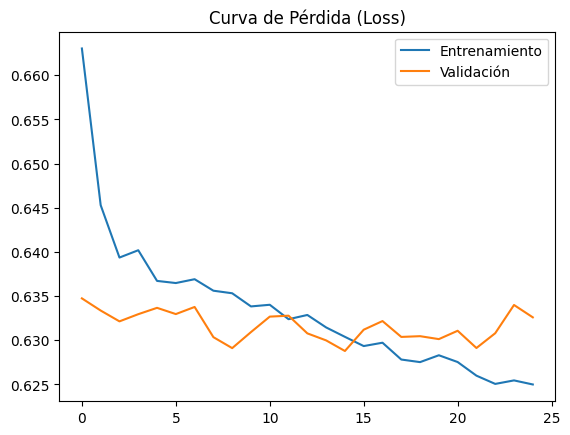

In [98]:
import matplotlib.pyplot as plt

# Graficar la pérdida
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida (Loss)')
plt.legend()
plt.show()

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.65      0.64      0.64      1717
           1       0.63      0.64      0.64      1659

    accuracy                           0.64      3376
   macro avg       0.64      0.64      0.64      3376
weighted avg       0.64      0.64      0.64      3376



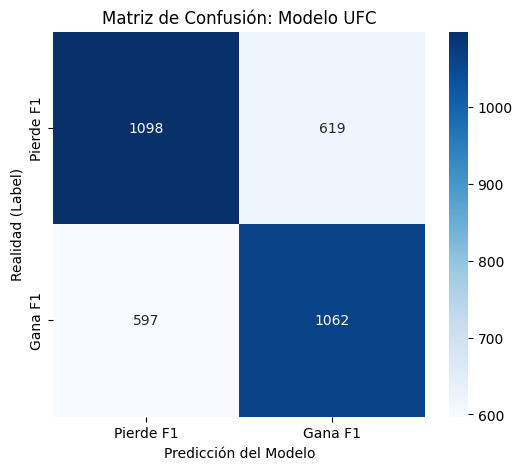

In [99]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# 1. Realizar predicciones con el set de test (datos que NUNCA ha visto)
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int) # Umbral del 50%

# 2. Generar el reporte de métricas
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# 3. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pierde F1', 'Gana F1'], 
            yticklabels=['Pierde F1', 'Gana F1'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Label)')
plt.title('Matriz de Confusión: Modelo UFC')
plt.show()

In [100]:
# 2. Calculamos la matriz
cm = confusion_matrix(y_test, y_pred)

# 3. Imprimimos los números desglosados
print("--- MATRIZ DE CONFUSIÓN (Valores Reales) ---")
print(f"Verdaderos Negativos (TN): {cm[0][0]}")
print(f"Falsos Positivos (FP): {cm[0][1]}")
print(f"Falsos Negativos (FN): {cm[1][0]}")
print(f"Verdaderos Positivos (VP): {cm[1][1]}")
print("-------------------------------------------")

# También imprimimos la matriz como array para doble chequeo
print("\nArray de la matriz:")
print(cm)

--- MATRIZ DE CONFUSIÓN (Valores Reales) ---
Verdaderos Negativos (TN): 1098
Falsos Positivos (FP): 619
Falsos Negativos (FN): 597
Verdaderos Positivos (VP): 1062
-------------------------------------------

Array de la matriz:
[[1098  619]
 [ 597 1062]]


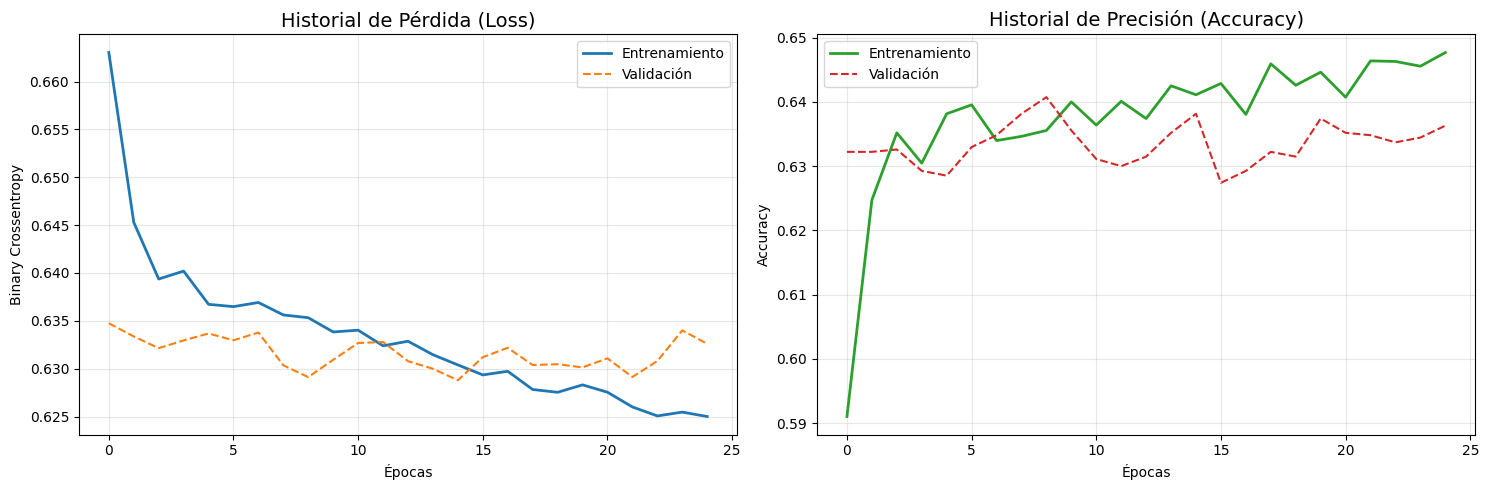

In [101]:
import matplotlib.pyplot as plt

# Crear una figura con dos subgráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica de Loss
ax1.plot(history.history['loss'], label='Entrenamiento', color='#1f77b4', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validación', color='#ff7f0e', linestyle='--')
ax1.set_title('Historial de Pérdida (Loss)', fontsize=14)
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Binary Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfica de Accuracy
ax2.plot(history.history['accuracy'], label='Entrenamiento', color='#2ca02c', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validación', color='#d62728', linestyle='--')
ax2.set_title('Historial de Precisión (Accuracy)', fontsize=14)
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [103]:
# 1. Datos de la pelea con las 12 columnas exactas
age_burns, age_malott = 39, 34
decay_burns = (age_burns - 30)**2 
decay_malott = (age_malott - 30)**2

datos_combate = {
    'Diff_Height': [-3],
    'Diff_Reach': [-2],
    'Diff_Age': [age_burns - age_malott],
    'Diff_Age_Decay': [decay_burns - decay_malott],
    'Diff_Recent_Form': [-1], 
    'Diff_Str_Def': [0.05],
    'Diff_TD_Def': [0.15],
    'Diff_Avg_Acc': [0.02],
    'Diff_Avg_Ctrl': [1.0],
    # Añadimos las columnas de Stance que el scaler espera
    'F1_Stance_Orthodox': [1], 
    'F1_Stance_Southpaw': [0],
    'F1_Stance_Switch': [0],
    'F2_Stance_Orthodox': [1], 
    'F2_Stance_Southpaw': [0],
    'F2_Stance_Switch': [0]
}

# 2. Crear DataFrame y asegurar el orden de columnas
X_live = pd.DataFrame(datos_combate)

# 3. Transformación e Inferencia
X_live_scaled = scaler.transform(X_live)
prob_val = model.predict(X_live_scaled)[0][0]

print(f"--- PREDICCIÓN FINAL ---")
print(f"Probabilidad para Burns (F1): {prob_val:.4f}")
print("Ganador:", "Burns" if prob_val > 0.5 else "Malott")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
--- PREDICCIÓN FINAL ---
Probabilidad para Burns (F1): 0.4570
Ganador: Malott


In [ ]:
# 1. Datos demográficos y biológicos
age_f1, age_f2 = 32, 35
decay_f1 = (age_f1 - 30)**2 if age_f1 > 30 else 0
decay_f2 = (age_f2 - 30)**2 if age_f2 > 30 else 0

# 2. Construcción de diferenciales con datos de carrera
datos_combate = {
    'Diff_Height': [3],          
    'Diff_Reach': [-3],           
    'Diff_Age': [age_f1 - age_f2],
    'Diff_Age_Decay': [decay_f1 - decay_f2],
    'Diff_Recent_Form': [2],       
    'Diff_Str_Def': [-0.20],       
    'Diff_TD_Def': [0.23],       
    'Diff_Avg_Acc': [0.17],        
    'Diff_Avg_Ctrl': [2.20],        
    # Stance
    'F1_Stance_Orthodox': [1], 'F1_Stance_Southpaw': [0], 'F1_Stance_Switch': [0],
    'F2_Stance_Orthodox': [1], 'F2_Stance_Southpaw': [0], 'F2_Stance_Switch': [0]
}

X_live = pd.DataFrame(datos_combate)
X_live_scaled = scaler.transform(X_live)
prob_val = model.predict(X_live_scaled)[0][0]

print(f"--- SIMULACIÓN BASADA EN ESTADÍSTICAS DE CARRERA ---")
print(f"Probabilidad para Chimaev: {prob_val:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
--- SIMULACIÓN BASADA EN ESTADÍSTICAS DE CARRERA ---
Probabilidad para Chimaev: 0.5432


## Comparativa con otros modelos de ML

In [104]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report

def mostrar_resultados(modelos, X_test, y_test):
    data = []
    for nombre, modelo in modelos.items():
        y_pred = modelo.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        sens = tp / (tp + fn)
        spec = tn / (tn + fp)
        data.append([acc, kappa, sens, spec])
    
    df = pd.DataFrame(data, index=modelos.keys(), 
                      columns=['Accuracy', 'Kappa', 'Sens.', 'Spec.'])
    return df.round(4)

# --- RF: Más árboles y mayor profundidad controlada ---
rf_model = RandomForestClassifier(
    n_estimators=500,           # Más árboles para reducir varianza
    max_depth=15,               # Permitimos un poco más de complejidad
    min_samples_leaf=4,         # Evita hojas con muy pocos datos (ruido)
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1                   # Usa todos los núcleos para ir más rápido
)

# --- GBDT: Aprendizaje más lento y profundo ---
gbdt_model = GradientBoostingClassifier(
    n_estimators=300, 
    learning_rate=0.03,         # Paso más pequeño para no pasarse de largo
    max_depth=6,                # Árboles un poco más altos
    subsample=0.8,              # Entrenamiento estocástico para generalizar
    random_state=42
)

# --- SVM: Ajuste de la regularización C ---
# C=0.1 suele ser un "dulce punto" entre margen y error en estos datos
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
base_svm = LinearSVC(C=0.1, dual=False, tol=1e-4, random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=5)

# Entrenamiento
rf_model.fit(X_train, y_train)
gbdt_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)

# --- CELDA 2: Evaluación ---
modelos_dict = {
    'Random Forest': rf_model,
    'GBDT': gbdt_model,
    'SVM': svm_model
}

display(mostrar_resultados(modelos_dict, X_test, y_test))

,Accuracy,Kappa,Sens.,Spec.
Random Forest,0.638,0.2762,0.6462,0.6302
GBDT,0.630,0.2605,0.6486,0.6121
SVM,0.636,0.2721,0.6450,0.6273
